## 1. Imports and shared constants

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, precision_score, recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

SENSOR_COLS = [
    "SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure",
]
SEQ_SENSORS = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp"]
SEQ_FEATURE_COLS = [
    f"{s}_{stat}" for s in SEQ_SENSORS
    for stat in (
        [f"roll_mean_{w}h" for w in (6, 12, 24)] + [f"roll_std_{w}h" for w in (6, 12, 24)]
        + [f"lag_{l}h" for l in (1, 3, 6)] + ["delta_6h"]
    )
]
ALL_FEATURE_COLS = SENSOR_COLS + SEQ_FEATURE_COLS

TARGETS = ["Fault_Within_6h", "Fault_Within_12h"]
RANDOM_STATE = 42
PALETTE = {False: "#3F7D5C", True: "#B23A2E"}

## 2. Load engineered dataset

Split is chronological within each vehicle: last 20% of each vehicle's own timeline
becomes its test set.

In [3]:
def chronological_split(data, group_col="user_profile", time_col="timestamp", test_frac=0.2):
    train_parts, test_parts = [], []
    for _, g in data.groupby(group_col):
        g = g.sort_values(time_col)
        cutoff = int(len(g) * (1 - test_frac))
        train_parts.append(g.iloc[:cutoff])
        test_parts.append(g.iloc[cutoff:])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(test_parts).reset_index(drop=True)


df_full = pd.read_csv(
    "../data/processed/driving_pattern_diagnostics_sequence_features.csv",
    parse_dates=["timestamp"],
)
df_full = df_full.sort_values(["user_profile", "timestamp"]).reset_index(drop=True)

print(f"{len(df_full):,} rows loaded, {len(ALL_FEATURE_COLS)} features "
      f"({len(SENSOR_COLS)} raw sensor + {len(SEQ_FEATURE_COLS)} rolling/lag/delta).")

175,108 rows loaded, 50 features (10 raw sensor + 40 rolling/lag/delta).


## 3. Build the three base pipelines + the soft-voting ensemble

All three base learners are class-weighted **at construction time**

- **Random Forest**
- **XGBoost** 
- **LightGBM** 


In [4]:
def build_pipelines(y_train, random_state=RANDOM_STATE):
    pos_rate = y_train.mean()
    scale_pos_weight = (1 - pos_rate) / pos_rate

    rf = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=12, class_weight="balanced",
            random_state=random_state, n_jobs=-1,
        )),
    ])

    xgb = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            scale_pos_weight=scale_pos_weight, eval_metric="logloss",
            random_state=random_state, n_jobs=-1,
        )),
    ])

    lgbm = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LGBMClassifier(
            n_estimators=300, max_depth=-1, learning_rate=0.1,
            class_weight="balanced", random_state=random_state, n_jobs=-1, verbosity=-1,
        )),
    ])

    ensemble = VotingClassifier(
        estimators=[("rf", rf), ("xgb", xgb), ("lgbm", lgbm)],
        voting="soft",
    )

    return {"Random Forest": rf, "XGBoost": xgb, "LightGBM": lgbm, "Ensemble (soft voting)": ensemble}

## 4. One reusable train/eval function, called once per horizon

Wrapping in a function so it runs identically for `Fault_Within_6h`
and `Fault_Within_12h`.

In [5]:
def train_eval_all_models(df_full, target, feature_cols=ALL_FEATURE_COLS):
    model_df = df_full.dropna(subset=[target]).copy()
    model_df[target] = model_df[target].astype(bool)

    train_df, test_df = chronological_split(model_df)
    X_train, y_train = train_df[feature_cols], train_df[target]
    X_test, y_test = test_df[feature_cols], test_df[target]

    print(f"=== {target} ===")
    print(f"Train: {len(train_df):,} rows, Test: {len(test_df):,} rows")
    print(f"Positive rate — train: {y_train.mean()*100:.2f}%, test: {y_test.mean()*100:.2f}%")
    print(f"Test set: {y_test.sum()} positive rows out of {len(y_test)}\n")

    models = build_pipelines(y_train)
    fitted, rows, preds = {}, [], {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        fitted[name] = model
        pred = model.predict(X_test)
        preds[name] = pred
        rows.append({
            "model": name,
            "macro_F1": f1_score(y_test, pred, average="macro"),
            "recall_positive": recall_score(y_test, pred, pos_label=True),
            "precision_positive": precision_score(y_test, pred, pos_label=True),
        })

    results_df = pd.DataFrame(rows).set_index("model").sort_values("macro_F1", ascending=False)
    return fitted, results_df, preds, (X_test, y_test)


all_results = {}
all_fitted = {}
all_preds = {}
all_test = {}

for target in TARGETS:
    fitted, results_df, preds, (X_test, y_test) = train_eval_all_models(df_full, target)
    all_results[target] = results_df
    all_fitted[target] = fitted
    all_preds[target] = preds
    all_test[target] = (X_test, y_test)
    print(results_df.round(4))
    print()

=== Fault_Within_6h ===
Train: 140,064 rows, Test: 35,020 rows
Positive rate — train: 8.97%, test: 9.39%
Test set: 3290 positive rows out of 35020

                        macro_F1  recall_positive  precision_positive
model                                                                
Ensemble (soft voting)    0.5998           0.5164              0.2326
Random Forest             0.5985           0.5939              0.2304
LightGBM                  0.5919           0.5064              0.2226
XGBoost                   0.5857           0.4666              0.2154

=== Fault_Within_12h ===
Train: 140,048 rows, Test: 35,012 rows
Positive rate — train: 16.99%, test: 17.81%
Test set: 6237 positive rows out of 35012

                        macro_F1  recall_positive  precision_positive
model                                                                
Random Forest             0.6111           0.5879              0.3235
Ensemble (soft voting)    0.6091           0.5097              0.3251


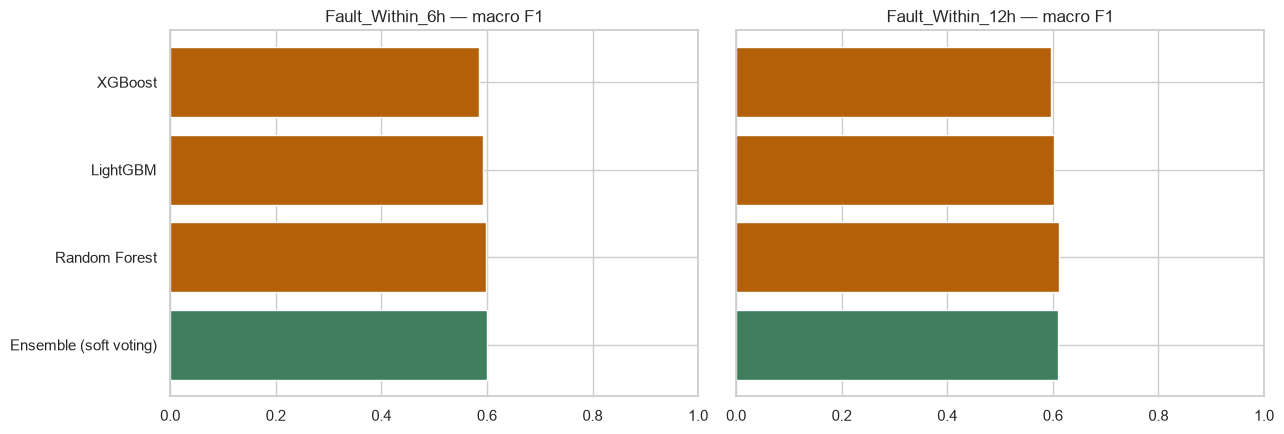

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, target in zip(axes, TARGETS):
    data = all_results[target].reset_index()
    colors = ["#B4600A" if m != "Ensemble (soft voting)" else "#3F7D5C" for m in data["model"]]
    ax.barh(data["model"], data["macro_F1"], color=colors)
    ax.set_xlim(0, 1)
    ax.set_title(f"{target} — macro F1")
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Reading this table

- The ensemble is only worth keeping if it **beats the best individual base model**, not
  just the average of the three — an ensemble that lands between a strong model and two
  weaker ones is *worse* than just using the strong model alone.
- Compare `Fault_Within_6h`'s numbers here to `03_sequence_classifier.ipynb`'s standalone
  RF (~0.60) / XGBoost (~0.59) macro F1 — the RF/XGBoost rows above should land close to
  those (small differences are expected: `03` used `compute_sample_weight`, this notebook
  uses `scale_pos_weight`, a different but comparable way of expressing the same class
  imbalance).
- `Fault_Within_12h` has a less extreme imbalance (17.15% positive vs. 9.05% for 6h) — expect
  higher macro F1 across the board, traded off against a fuzzier "when exactly" signal for
  the fleet manager.

## 6. Confusion matrices

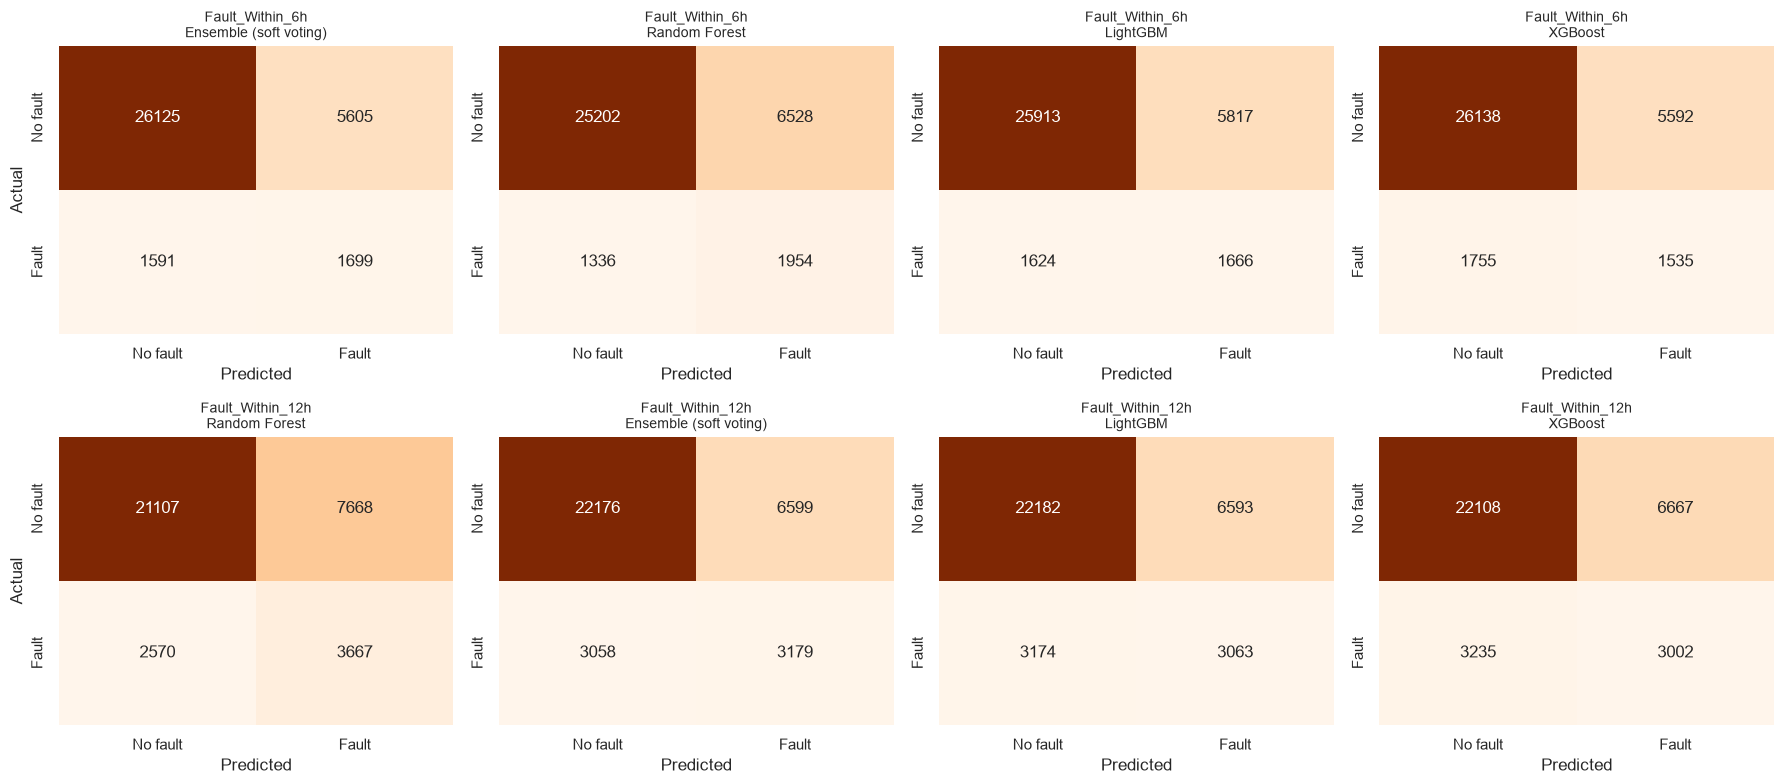

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for row, target in enumerate(TARGETS):
    _, y_test = all_test[target]
    for col, name in enumerate(all_results[target].index):
        ax = axes[row, col]
        cm = confusion_matrix(y_test, all_preds[target][name], labels=[False, True])
        sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", cbar=False,
                    xticklabels=["No fault", "Fault"], yticklabels=["No fault", "Fault"], ax=ax)
        ax.set_title(f"{target}\n{name}", fontsize=10)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual" if col == 0 else "")
plt.tight_layout()
plt.show()

## 7. Full classification reports (both classes, both horizons)

The scoreboard above only shows the positive class + macro F1 — the full report below
also shows the negative-class (majority) precision/recall, useful for spotting a model
that's trading away negative-class precision for positive-class recall more aggressively
than the others.

In [8]:
for target in TARGETS:
    _, y_test = all_test[target]
    print(f"{'='*70}\n{target}\n{'='*70}")
    for name, pred in all_preds[target].items():
        print(f"--- {name} ---")
        print(classification_report(y_test, pred, labels=[False, True],
                                     target_names=["No fault", "Fault"], digits=3))

Fault_Within_6h
--- Random Forest ---
              precision    recall  f1-score   support

    No fault      0.950     0.794     0.865     31730
       Fault      0.230     0.594     0.332      3290

    accuracy                          0.775     35020
   macro avg      0.590     0.694     0.599     35020
weighted avg      0.882     0.775     0.815     35020

--- XGBoost ---
              precision    recall  f1-score   support

    No fault      0.937     0.824     0.877     31730
       Fault      0.215     0.467     0.295      3290

    accuracy                          0.790     35020
   macro avg      0.576     0.645     0.586     35020
weighted avg      0.869     0.790     0.822     35020

--- LightGBM ---
              precision    recall  f1-score   support

    No fault      0.941     0.817     0.874     31730
       Fault      0.223     0.506     0.309      3290

    accuracy                          0.788     35020
   macro avg      0.582     0.662     0.592     35020
wei

## 8. Save models


In [9]:
os.makedirs("../models", exist_ok=True)

name_to_slug = {
    "Random Forest": "random_forest",
    "XGBoost": "xgboost",
    "LightGBM": "lightgbm",
    "Ensemble (soft voting)": "ensemble",
}

for target in TARGETS:
    horizon = target.replace("Fault_Within_", "").lower()  # "6h" / "12h"
    for name, model in all_fitted[target].items():
        slug = name_to_slug[name]
        path = f"../models/ensemble_{horizon}_{slug}.joblib"
        joblib.dump(model, path)
    print(f"Saved 4 models for {target} to ../models/ensemble_{horizon}_*.joblib")

Saved 4 models for Fault_Within_6h to ../models/ensemble_6h_*.joblib
Saved 4 models for Fault_Within_12h to ../models/ensemble_12h_*.joblib


In [10]:
best_individual = results_df.drop("Ensemble (soft voting)")["macro_F1"].max()
ensemble_score = results_df.loc["Ensemble (soft voting)", "macro_F1"]
print("Ensemble wins" if ensemble_score > best_individual else "Ensemble doesn't add value here")
all_results["Fault_Within_12h"].sort_values("macro_F1", ascending=False)

Ensemble doesn't add value here


,macro_F1,recall_positive,precision_positive
model,,,
Random Forest,0.611090,0.587943,0.323511
Ensemble (soft voting),0.609100,0.509700,0.325118
LightGBM,0.602510,0.491101,0.317212
XGBoost,0.597249,0.481321,0.310477
